In [55]:
import matplotlib.pyplot as plt
import pandas as pd



In [56]:
df=pd.read_csv(r"C:\Users\Dell\Downloads\archive (24)\smart_grid_stability_augmented.csv")

In [57]:
df.shape

(60000, 14)

In [27]:
df.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='str')

In [61]:
print(df.head())

       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4      stab     stabf  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  0.055347  unstable  
1 -1.255012  0.413441  0.862414  0.562139  0.781760 -0.005957    stable  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  0.003471  unstable  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  0.028871  unstable  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  0.049860  unstable  


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    60000 non-null  float64
 1   tau2    60000 non-null  float64
 2   tau3    60000 non-null  float64
 3   tau4    60000 non-null  float64
 4   p1      60000 non-null  float64
 5   p2      60000 non-null  float64
 6   p3      60000 non-null  float64
 7   p4      60000 non-null  float64
 8   g1      60000 non-null  float64
 9   g2      60000 non-null  float64
 10  g3      60000 non-null  float64
 11  g4      60000 non-null  float64
 12  stab    60000 non-null  float64
 13  stabf   60000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 6.4 MB


In [62]:
from sklearn .preprocessing import LabelBinarizer
lb=LabelBinarizer()
df['stabf']=lb.fit_transform(df['stabf']).ravel()
df['stabf'].head()

0    1
1    0
2    1
3    1
4    1
Name: stabf, dtype: int64

In [64]:
print(df.corr())

           tau1      tau2      tau3      tau4        p1        p2        p3  \
tau1   1.000000 -0.002550 -0.002550 -0.002550  0.027183 -0.015739 -0.015739   
tau2  -0.002550  1.000000  0.005554  0.005554  0.003004 -0.004473 -0.000372   
tau3  -0.002550  0.005554  1.000000  0.005554  0.003004 -0.000372 -0.004473   
tau4  -0.002550  0.005554  0.005554  1.000000  0.003004 -0.000372 -0.000372   
p1     0.027183  0.003004  0.003004  0.003004  1.000000 -0.578983 -0.578983   
p2    -0.015739 -0.004473 -0.000372 -0.000372 -0.578983  1.000000  0.002833   
p3    -0.015739 -0.000372 -0.004473 -0.000372 -0.578983  0.002833  1.000000   
p4    -0.015739 -0.000372 -0.000372 -0.004473 -0.578983  0.002833  0.002833   
g1     0.010521 -0.005832 -0.005832 -0.005832  0.000721 -0.000417 -0.000417   
g2     0.006522  0.009865  0.002102  0.002102  0.000341 -0.002141  0.000774   
g3     0.006522  0.002102  0.009865  0.002102  0.000341  0.000774 -0.002141   
g4     0.006522  0.002102  0.002102  0.009865  0.000

In [50]:
from sklearn.model_selection import train_test_split
X=df.drop(['stabf','stab'],axis=1)
y=df['stabf']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y,shuffle=True)

In [51]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,StackingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,log_loss,roc_auc_score,f1_score

In [34]:
import numpy as np
import xgboost as xgb
from scikeras.wrappers import KerasClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

# 1. دالة واحدة فقط لتعريف هيكل شبكة الديب ليرنينج
def make_nn(meta):
    return Sequential([
        Dense(64, activation='relu', input_shape=(meta["n_features_in_"],)),
        Dense(32, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

# 2. حساب نسبة الموازنة
ratio = np.sum(y_train == 0) / np.sum(y_train == 1)

# 3. إعداد الموديلات مباشرة (مضمن فيها موديل الديب ليرنينج)
models = [

    ('nn_model', KerasClassifier(model=make_nn, loss='binary_crossentropy', optimizer='adam', epochs=30, batch_size=32, verbose=0)),
    ('LR', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ('RF', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ('DT', DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42, class_weight='balanced')),
    ('XGB', xgb.XGBClassifier(random_state=42, scale_pos_weight=ratio))
]

# 4. الـ Stacking والتدريب والتوقع
stack = StackingClassifier(estimators=models, final_estimator=LogisticRegression(max_iter=1000, random_state=42), cv=5, n_jobs=1)
stack.fit(X_train, y_train)

y_pred = stack.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)







C:\Users\Dell\PycharmProjects\PythonProject9\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Dell\PycharmProjects\PythonProject9\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Dell\PycharmProjects\PythonProject9\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the mode

In [41]:
y_train_pred=stack.predict(X_train)
y_pred=stack.predict(X_test)
test_acc=accuracy_score(y_test, y_pred)
train_acc=accuracy_score(y_train, y_train_pred)
print(test_acc," : ",train_acc)

0.9859166666666667  :  0.999625


In [42]:
print(cm)
print(classification_report(y_test,y_pred))

[[4258   86]
 [  83 7573]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4344
           1       0.99      0.99      0.99      7656

    accuracy                           0.99     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.99      0.99      0.99     12000



<Axes: >

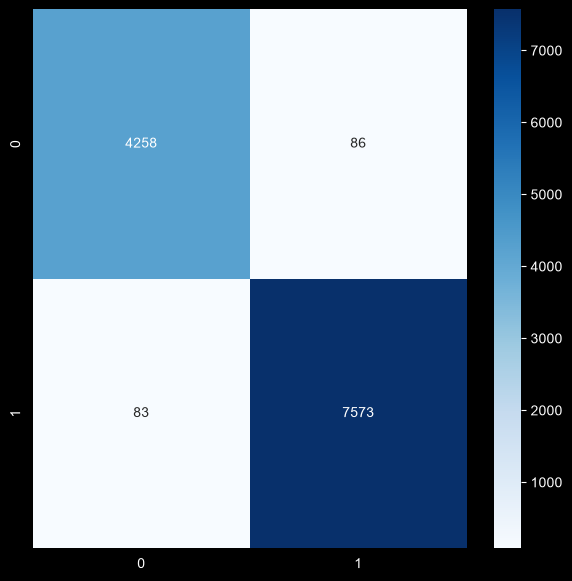

In [46]:
import seaborn as sns
plt.figure(figsize=(7,7))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')


In [37]:
import dill
with open('final project.pkl', 'wb') as f:
   dill.dump(stack, f)
print("saved successfully")



saved successfully
